In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score



In [2]:
df = pd.read_csv("transaction_fraud_dataset.csv")
df.head()

,transaction_amount,transaction_time,customer_age,distance_from_home,previous_fraud_history,merchant_risk_score,num_transactions_last_24hrs,account_type,region,transaction_method,fraud_label
0,93.85,21,20,8.38,0,0.40,2,Current,West,Online,0
1,602.02,19,57,16.17,0,0.91,1,Savings,East,POS,0
2,263.35,6,44,7.33,0,0.44,6,Current,South,POS,0
3,182.59,2,36,118.89,0,0.53,4,Savings,South,ATM,0
4,33.92,4,26,3.26,0,0.35,2,Savings,Central,POS,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_amount           12000 non-null  float64
 1   transaction_time             12000 non-null  int64  
 2   customer_age                 12000 non-null  int64  
 3   distance_from_home           12000 non-null  float64
 4   previous_fraud_history       12000 non-null  int64  
 5   merchant_risk_score          12000 non-null  float64
 6   num_transactions_last_24hrs  12000 non-null  int64  
 7   account_type                 12000 non-null  object 
 8   region                       12000 non-null  object 
 9   transaction_method           12000 non-null  object 
 10  fraud_label                  12000 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 1.0+ MB


In [4]:
df.isnull().sum()

transaction_amount             0
transaction_time               0
customer_age                   0
distance_from_home             0
previous_fraud_history         0
merchant_risk_score            0
num_transactions_last_24hrs    0
account_type                   0
region                         0
transaction_method             0
fraud_label                    0
dtype: int64

In [5]:
le_account = LabelEncoder()
le_region = LabelEncoder()
le_method = LabelEncoder()

df["account_type"] = le_account.fit_transform(df["account_type"])
df["region"] = le_region.fit_transform(df["region"])
df["transaction_method"] = le_method.fit_transform(df["transaction_method"])

In [6]:
X = df.drop("fraud_label", axis=1)
y = df["fraud_label"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1:", f1_score(y_test, y_pred_rf, average='weighted'))
print("AUC:", roc_auc_score(y_test, y_prob_rf, multi_class='ovr'))

Random Forest
Accuracy: 0.9920833333333333
Precision: 0.9920671485821335
Recall: 0.9920833333333333
F1: 0.9910771764023983
AUC: 0.9987788197967197


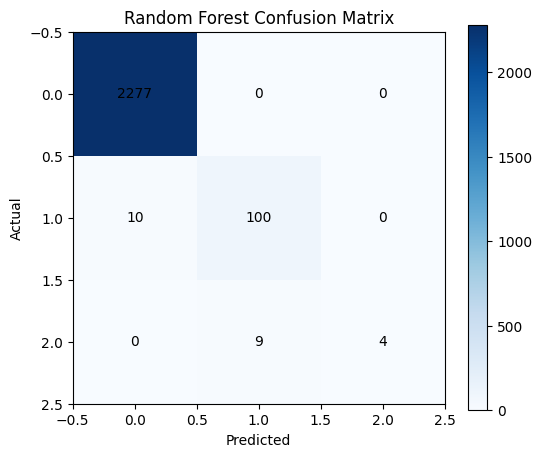

In [20]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
plt.imshow(cm_rf, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [15]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1:", f1_score(y_test, y_pred_lr, average='weighted'))
print("AUC:", roc_auc_score(y_test, y_prob_lr, multi_class='ovr'))

Logistic Regression
Accuracy: 0.9491666666666667
Precision: 0.9349784075573551
Recall: 0.9491666666666667
F1: 0.9399292028759246
AUC: 0.9554011578415084


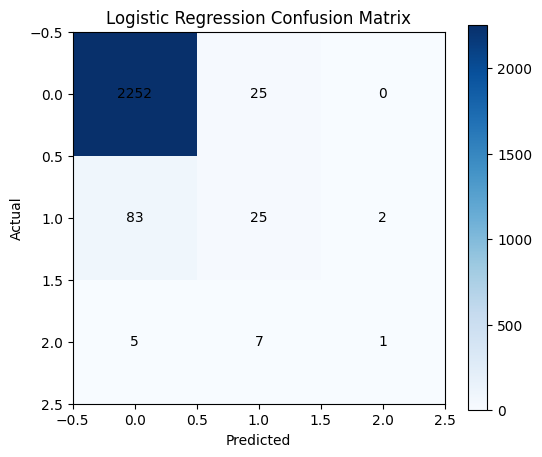

In [21]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
plt.imshow(cm_lr, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1:", f1_score(y_test, y_pred_knn, average='weighted'))
print("AUC:", roc_auc_score(y_test, y_prob_knn, multi_class='ovr'))

KNN
Accuracy: 0.9558333333333333
Precision: 0.9439331855100179
Recall: 0.9558333333333333
F1: 0.9483739024894121
AUC: 0.8600080082756328


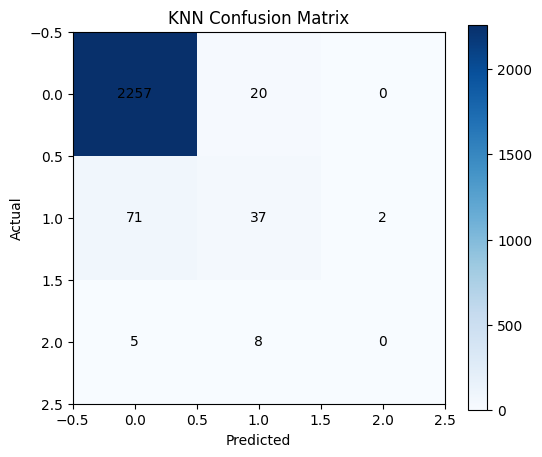

In [22]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
plt.imshow(cm_knn, cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_knn.shape[0]):
    for j in range(cm_knn.shape[1]):
        plt.text(j, i, cm_knn[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [17]:
svc = SVC(probability=True)
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)
y_prob_svc = svc.predict_proba(X_test)

print("SVC")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svc, average='weighted'))
print("F1:", f1_score(y_test, y_pred_svc, average='weighted'))
print("AUC:", roc_auc_score(y_test, y_prob_svc, multi_class='ovr'))

SVC
Accuracy: 0.9566666666666667
Precision: 0.9421874765231761
Recall: 0.9566666666666667
F1: 0.9465522109706679
AUC: 0.9836438055544342


C:\Users\hp\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


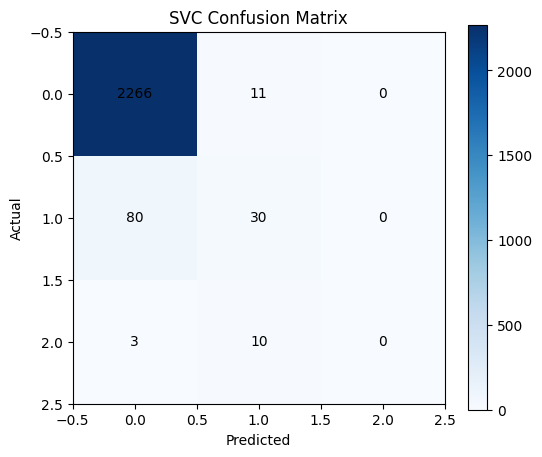

In [23]:
cm_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(6,5))
plt.imshow(cm_svc, cmap="Blues")
plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_svc.shape[0]):
    for j in range(cm_svc.shape[1]):
        plt.text(j, i, cm_svc[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [18]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)

print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1:", f1_score(y_test, y_pred_nb, average='weighted'))
print("AUC:", roc_auc_score(y_test, y_prob_nb, multi_class='ovr'))

Naive Bayes
Accuracy: 0.9179166666666667
Precision: 0.9364800347222223
Recall: 0.9179166666666667
F1: 0.9257025810833758
AUC: 0.9201987445113763


C:\Users\hp\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


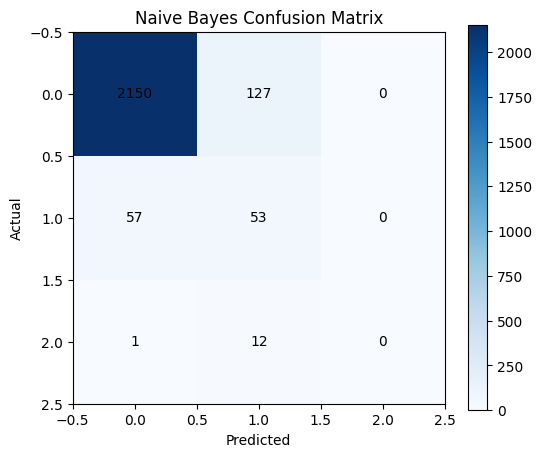

In [24]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
plt.imshow(cm_nb, cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_nb.shape[0]):
    for j in range(cm_nb.shape[1]):
        plt.text(j, i, cm_nb[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [19]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)

print("MLP")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_mlp, average='weighted'))
print("F1:", f1_score(y_test, y_pred_mlp, average='weighted'))
print("AUC:", roc_auc_score(y_test, y_prob_mlp, multi_class='ovr'))

MLP
Accuracy: 0.9795833333333334
Precision: 0.977438687620709
Recall: 0.9795833333333334
F1: 0.978258401062832
AUC: 0.9915164225307778


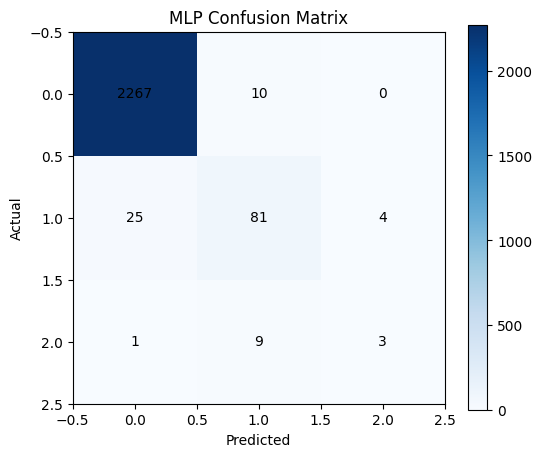

In [25]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,5))
plt.imshow(cm_mlp, cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        plt.text(j, i, cm_mlp[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

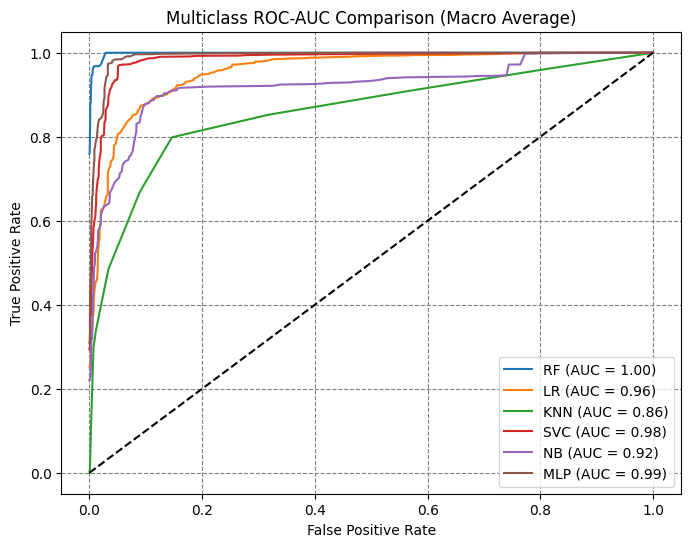

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

def plot_roc_macro(y_prob, model_name):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(classes)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= len(classes)

    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr, label=f"{model_name} (AUC = {macro_auc:.2f})")



plot_roc_macro(y_prob_rf, "RF")
plot_roc_macro(y_prob_lr, "LR")
plot_roc_macro(y_prob_knn, "KNN")
plot_roc_macro(y_prob_svc, "SVC")
plot_roc_macro(y_prob_nb, "NB")
plot_roc_macro(y_prob_mlp, "MLP")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC-AUC Comparison (Macro Average)")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()

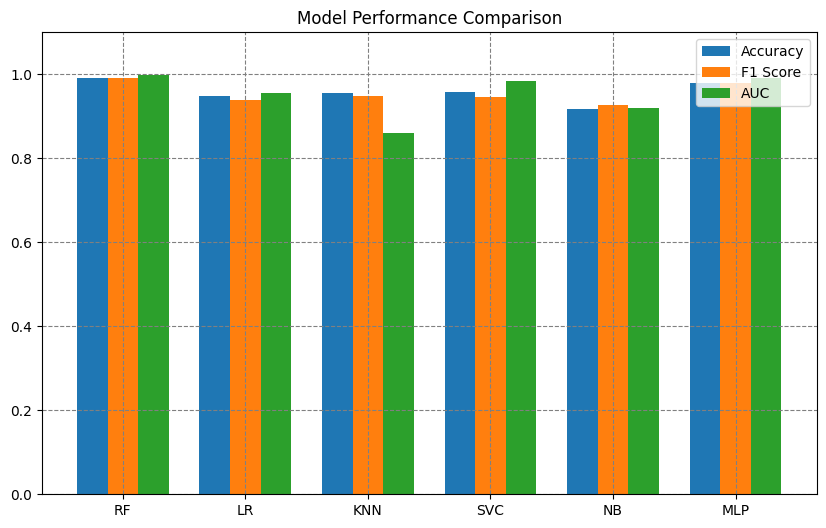

In [33]:
import matplotlib.pyplot as plt
import numpy as np

models = ['RF', 'LR', 'KNN', 'SVC', 'NB', 'MLP']

accuracy = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svc),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_mlp)
]

f1 = [
    f1_score(y_test, y_pred_rf, average='weighted'),
    f1_score(y_test, y_pred_lr, average='weighted'),
    f1_score(y_test, y_pred_knn, average='weighted'),
    f1_score(y_test, y_pred_svc, average='weighted'),
    f1_score(y_test, y_pred_nb, average='weighted'),
    f1_score(y_test, y_pred_mlp, average='weighted')
]

auc_scores = [
    roc_auc_score(y_test, y_prob_rf, multi_class='ovr'),
    roc_auc_score(y_test, y_prob_lr, multi_class='ovr'),
    roc_auc_score(y_test, y_prob_knn, multi_class='ovr'),
    roc_auc_score(y_test, y_prob_svc, multi_class='ovr'),
    roc_auc_score(y_test, y_prob_nb, multi_class='ovr'),
    roc_auc_score(y_test, y_prob_mlp, multi_class='ovr')
]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, f1, width, label='F1 Score')
plt.bar(x + width, auc_scores, width, label='AUC')

plt.xticks(x, models)
plt.ylim(0,1.1)
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()

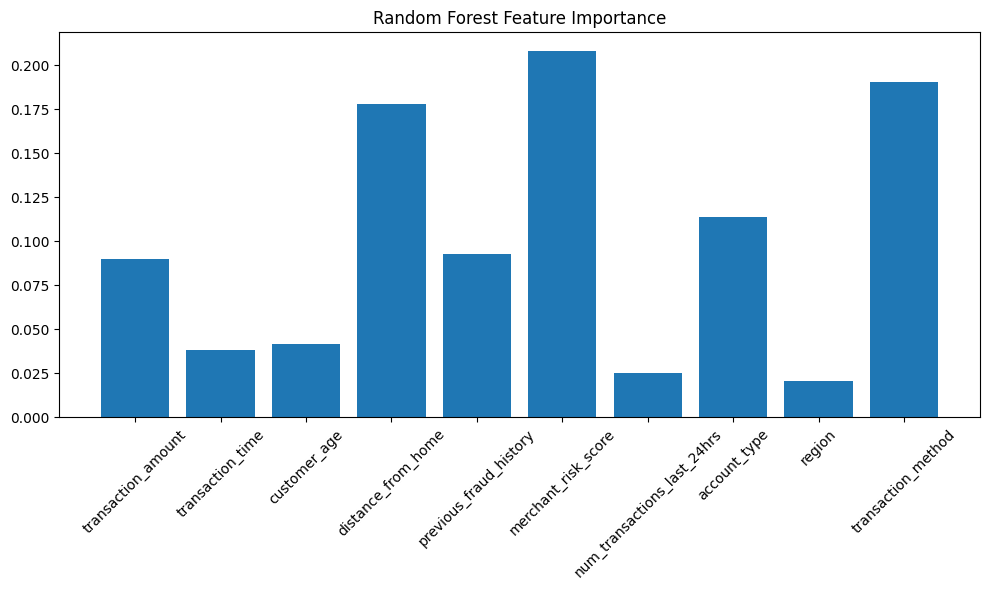

In [34]:
importances = rf.feature_importances_
feature_names = df.drop("fraud_label", axis=1).columns

plt.figure(figsize=(10,6))
plt.bar(feature_names, importances)
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

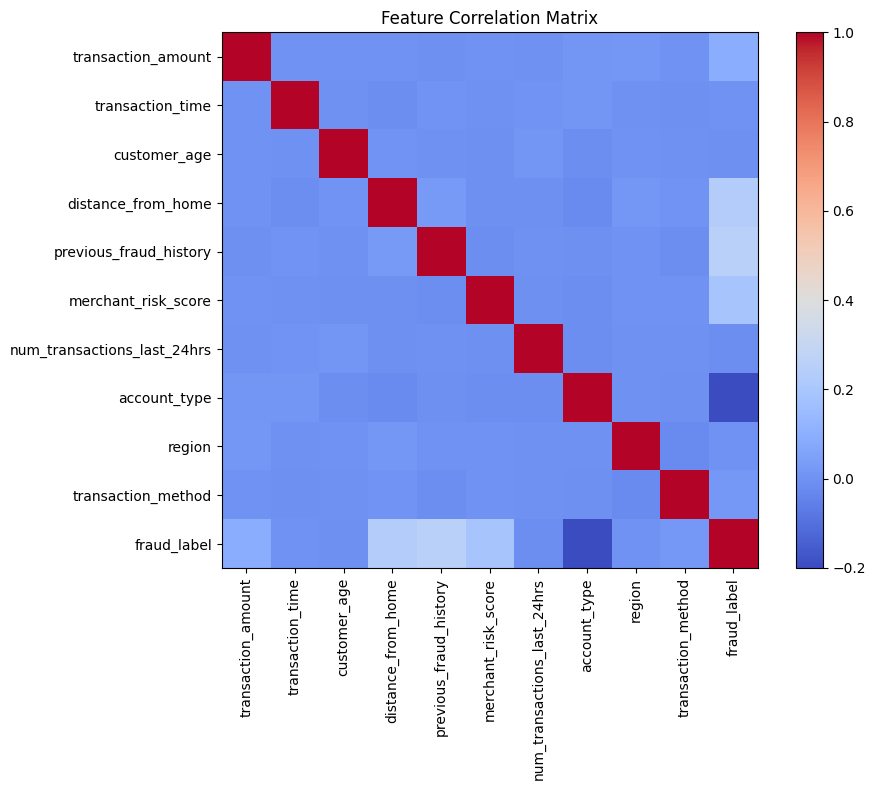

In [42]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

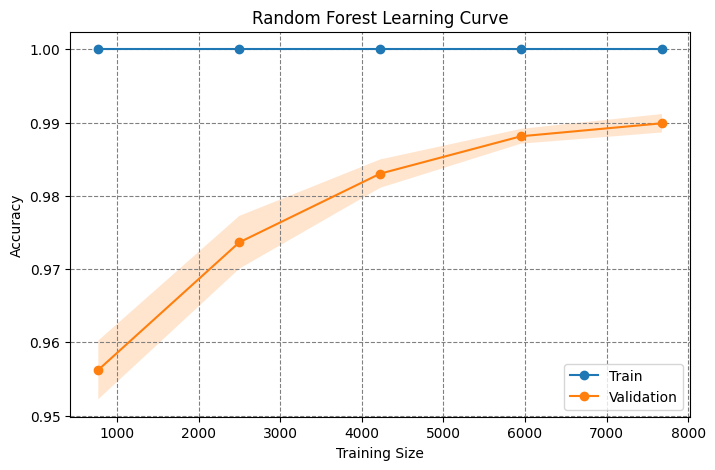

In [40]:
from sklearn.model_selection import learning_curve


rf = RandomForestClassifier(random_state=42)

train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_rf, train_scores_rf.mean(axis=1), marker='o', label="Train")
plt.plot(train_sizes_rf, val_scores_rf.mean(axis=1), marker='o', label="Validation")
plt.fill_between(train_sizes_rf,
                 train_scores_rf.mean(axis=1) - train_scores_rf.std(axis=1),
                 train_scores_rf.mean(axis=1) + train_scores_rf.std(axis=1),
                 alpha=0.2)
plt.fill_between(train_sizes_rf,
                 val_scores_rf.mean(axis=1) - val_scores_rf.std(axis=1),
                 val_scores_rf.mean(axis=1) + val_scores_rf.std(axis=1),
                 alpha=0.2)

plt.title("Random Forest Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()

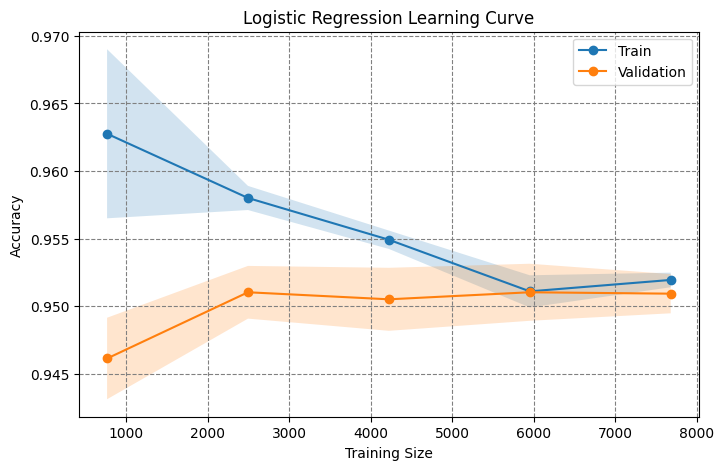

In [43]:
lr = LogisticRegression(max_iter=500)

train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_lr, train_scores_lr.mean(axis=1), marker='o', label="Train")
plt.plot(train_sizes_lr, val_scores_lr.mean(axis=1), marker='o', label="Validation")

plt.fill_between(train_sizes_lr,
                 train_scores_lr.mean(axis=1) - train_scores_lr.std(axis=1),
                 train_scores_lr.mean(axis=1) + train_scores_lr.std(axis=1),
                 alpha=0.2)

plt.fill_between(train_sizes_lr,
                 val_scores_lr.mean(axis=1) - val_scores_lr.std(axis=1),
                 val_scores_lr.mean(axis=1) + val_scores_lr.std(axis=1),
                 alpha=0.2)

plt.title("Logistic Regression Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()

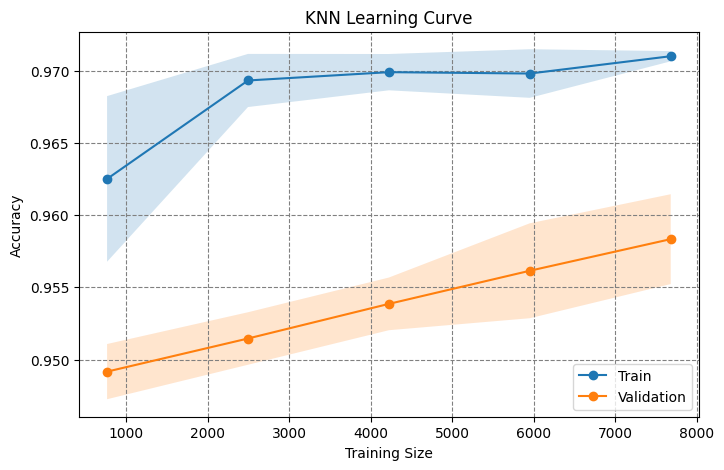

In [44]:
knn = KNeighborsClassifier(n_neighbors=5)

train_sizes_knn, train_scores_knn, val_scores_knn = learning_curve(
    knn,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_knn, train_scores_knn.mean(axis=1), marker='o', label="Train")
plt.plot(train_sizes_knn, val_scores_knn.mean(axis=1), marker='o', label="Validation")

plt.fill_between(train_sizes_knn,
                 train_scores_knn.mean(axis=1) - train_scores_knn.std(axis=1),
                 train_scores_knn.mean(axis=1) + train_scores_knn.std(axis=1),
                 alpha=0.2)

plt.fill_between(train_sizes_knn,
                 val_scores_knn.mean(axis=1) - val_scores_knn.std(axis=1),
                 val_scores_knn.mean(axis=1) + val_scores_knn.std(axis=1),
                 alpha=0.2)

plt.title("KNN Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()

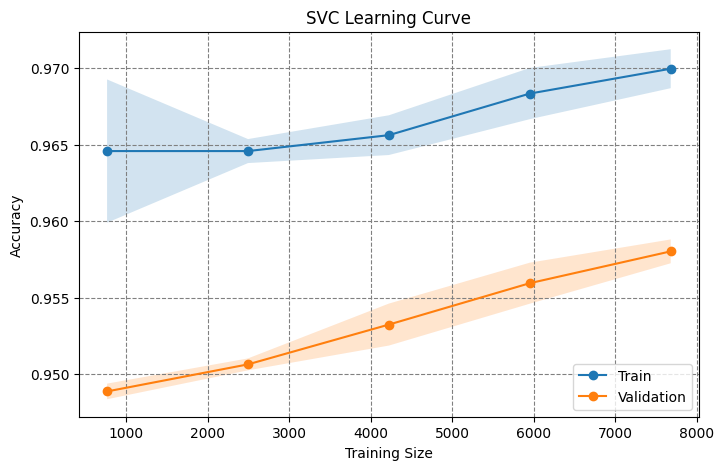

In [45]:
svc = SVC(probability=True)

train_sizes_svc, train_scores_svc, val_scores_svc = learning_curve(
    svc,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_svc, train_scores_svc.mean(axis=1), marker='o', label="Train")
plt.plot(train_sizes_svc, val_scores_svc.mean(axis=1), marker='o', label="Validation")

plt.fill_between(train_sizes_svc,
                 train_scores_svc.mean(axis=1) - train_scores_svc.std(axis=1),
                 train_scores_svc.mean(axis=1) + train_scores_svc.std(axis=1),
                 alpha=0.2)

plt.fill_between(train_sizes_svc,
                 val_scores_svc.mean(axis=1) - val_scores_svc.std(axis=1),
                 val_scores_svc.mean(axis=1) + val_scores_svc.std(axis=1),
                 alpha=0.2)

plt.title("SVC Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()

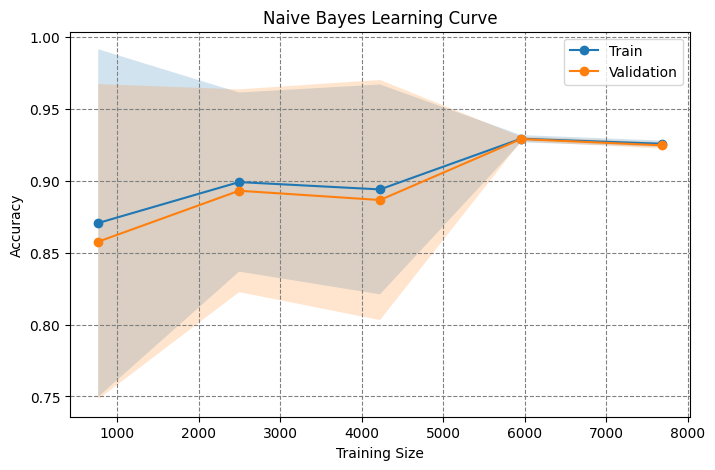

In [46]:
nb = GaussianNB()

train_sizes_nb, train_scores_nb, val_scores_nb = learning_curve(
    nb,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_nb, train_scores_nb.mean(axis=1), marker='o', label="Train")
plt.plot(train_sizes_nb, val_scores_nb.mean(axis=1), marker='o', label="Validation")

plt.fill_between(train_sizes_nb,
                 train_scores_nb.mean(axis=1) - train_scores_nb.std(axis=1),
                 train_scores_nb.mean(axis=1) + train_scores_nb.std(axis=1),
                 alpha=0.2)

plt.fill_between(train_sizes_nb,
                 val_scores_nb.mean(axis=1) - val_scores_nb.std(axis=1),
                 val_scores_nb.mean(axis=1) + val_scores_nb.std(axis=1),
                 alpha=0.2)

plt.title("Naive Bayes Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()

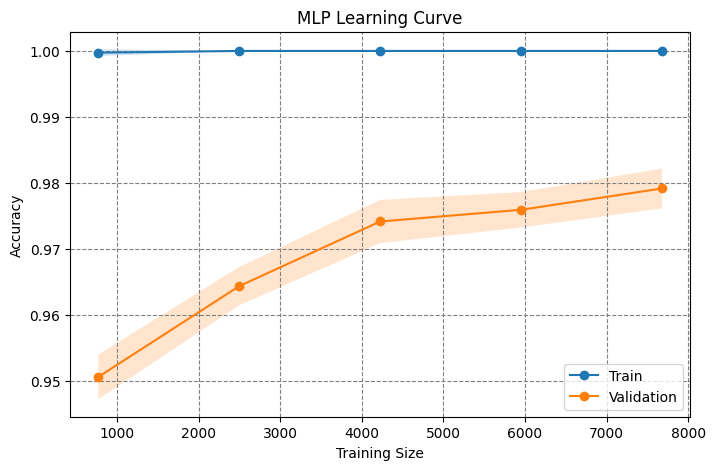

In [47]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)

train_sizes_mlp, train_scores_mlp, val_scores_mlp = learning_curve(
    mlp,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_mlp, train_scores_mlp.mean(axis=1), marker='o', label="Train")
plt.plot(train_sizes_mlp, val_scores_mlp.mean(axis=1), marker='o', label="Validation")

plt.fill_between(train_sizes_mlp,
                 train_scores_mlp.mean(axis=1) - train_scores_mlp.std(axis=1),
                 train_scores_mlp.mean(axis=1) + train_scores_mlp.std(axis=1),
                 alpha=0.2)

plt.fill_between(train_sizes_mlp,
                 val_scores_mlp.mean(axis=1) - val_scores_mlp.std(axis=1),
                 val_scores_mlp.mean(axis=1) + val_scores_mlp.std(axis=1),
                 alpha=0.2)

plt.title("MLP Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', color='gray')
plt.show()